In [1]:
import sys, os
sys.path.insert(0, "/media/crk/vol3/rt/lciba")
os.chdir("/media/crk/vol3/rt/lciba")

import torch, matplotlib.pyplot as plt
from scripts.utils import load_model, load_text, load_image
from scripts.methods import vision_heatmap_lciba, vision_heatmap_iba

model, preprocess = load_model("ViT-B/32")
img_t, pil = load_image("images/cat.jpg", preprocess)
txt_t = load_text("a cat sitting on a table")
kwargs = dict(layer_idx=9, beta=0.1, var=1.0, lr=1.0, train_steps=10, progbar=False)

[utils] Loaded CLIP ViT-B/32 on cuda
[utils] Vision blocks: 12
[utils] Text blocks:   12


In [2]:
vmap_lciba_first = vision_heatmap_lciba(txt_t, img_t, model, **kwargs)
print(f"LC-IBA first — std: {vmap_lciba_first.std():.4f}")

/media/crk/vol3/rt/lciba/scripts/iba.py:149: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(


LC-IBA first — std: 0.1485


In [3]:
vmap_m2ib = vision_heatmap_iba(txt_t, img_t, model, **kwargs)
print(f"M2IB — std: {vmap_m2ib.std():.4f}")

M2IB — std: 0.1707


In [4]:
vmap_lciba_second = vision_heatmap_lciba(txt_t, img_t, model, **kwargs)
print(f"LC-IBA second — std: {vmap_lciba_second.std():.4f}")

LC-IBA second — std: 0.1534


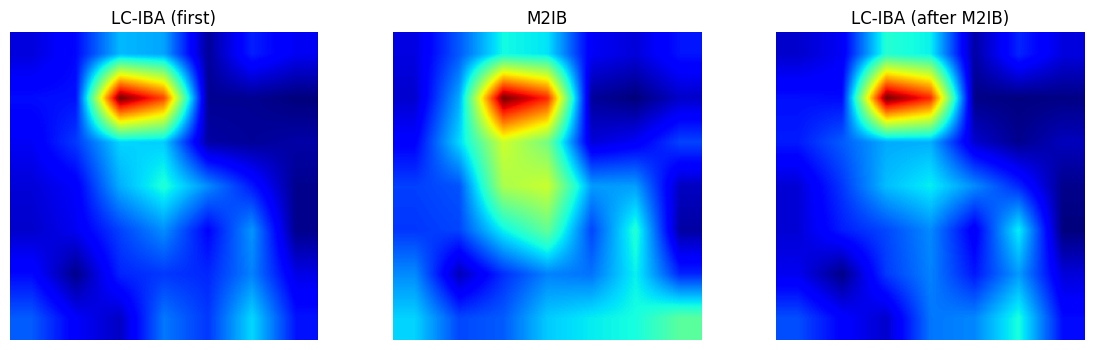

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, vmap, title in zip(axes,
    [vmap_lciba_first, vmap_m2ib, vmap_lciba_second],
    ["LC-IBA (first)", "M2IB", "LC-IBA (after M2IB)"]):
    ax.imshow(vmap, cmap='jet'); ax.set_title(title); ax.axis('off')
plt.show()

M2IB (baseline)                 std=0.1645
Option A only (hooks)           std=0.1601
Option B only (prior)           std=0.1896
LC-IBA full (A+B)               std=0.1858


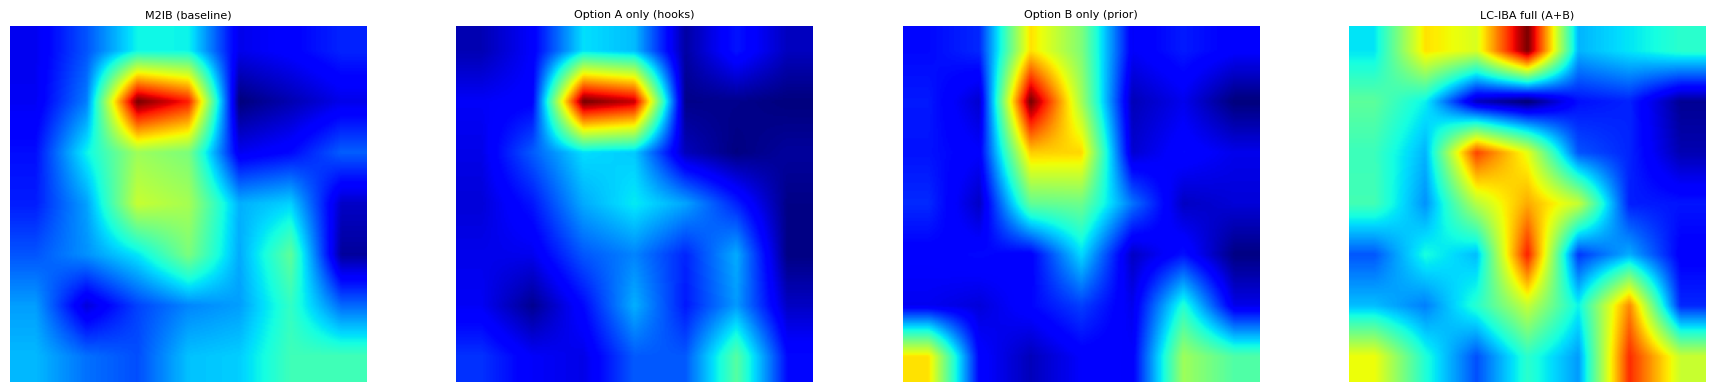

In [6]:
from scripts.iba import IBAInterpreter, InformationBottleneck
from scripts.methods import extract_bert_layer, extract_feature_map, get_compression_estimator
from scripts.libragrad import compute_libragrad_vision_saliency, prepare_vision_prior

layer     = extract_bert_layer(model.vision_model, 9)
features  = extract_feature_map(model.vision_model, 9, img_t)
estimator = get_compression_estimator(1.0, layer, features)
target    = model.vision_model.transformer.resblocks[9]
vmap_lg   = compute_libragrad_vision_saliency(model, img_t, txt_t, target)
prior     = prepare_vision_prior(vmap_lg, hidden_dim=features.shape[-1])

configs = {
    "M2IB (baseline)":        dict(use_libragrad=False, libragrad_init=False, prior=None),
    "Option A only (hooks)":  dict(use_libragrad=True,  libragrad_init=False, prior=None),
    "Option B only (prior)":  dict(use_libragrad=False, libragrad_init=True,  prior=prior),
    "LC-IBA full (A+B)":      dict(use_libragrad=True,  libragrad_init=True,  prior=prior),
}

vmaps = {}
for name, cfg in configs.items():
    reader = IBAInterpreter(model, estimator, beta=0.1, steps=10,
                            use_libragrad=cfg["use_libragrad"],
                            libragrad_init=cfg["libragrad_init"])
    vmap = reader.vision_heatmap(txt_t, img_t, prior=cfg["prior"])
    vmaps[name] = vmap
    print(f"{name:30s}  std={vmap.std():.4f}")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, vmap) in zip(axes, vmaps.items()):
    ax.imshow(vmap, cmap='jet'); ax.set_title(name, fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()

In [7]:
from scripts.libragrad import compute_libragrad_text_saliency, prepare_text_prior

# Text layer + estimator
text_layer     = extract_bert_layer(model.text_model, 9)
text_features  = extract_feature_map(model.text_model, 9, txt_t)
text_estimator = get_compression_estimator(1.0, text_layer, text_features)

# LibraGrad text prior
tmap_lg   = compute_libragrad_text_saliency(model, img_t, txt_t,
                model.text_model.transformer.resblocks[9])
text_prior = prepare_text_prior(tmap_lg, hidden_dim=text_features.shape[-1])

configs_to_test = {
    "M2IB":            dict(use_libragrad=False, libragrad_init=False),
    "LC-IBA Option A": dict(use_libragrad=True,  libragrad_init=False),
    "LC-IBA Option B": dict(use_libragrad=False, libragrad_init=True),
}

for name, cfg in configs_to_test.items():
    # Vision reader
    v_reader = IBAInterpreter(model, estimator, beta=0.1, steps=10,
                              use_libragrad=cfg["use_libragrad"],
                              libragrad_init=cfg["libragrad_init"])
    vmap = v_reader.vision_heatmap(txt_t, img_t,
                                   prior=prior if cfg["libragrad_init"] else None)

    # Text reader (separate instance, text layer)
    t_reader = IBAInterpreter(model, text_estimator, beta=0.1, steps=10,
                              use_libragrad=cfg["use_libragrad"],
                              libragrad_init=cfg["libragrad_init"])
    tmap = t_reader.text_heatmap(txt_t, img_t,
                                  prior=text_prior if cfg["libragrad_init"] else None)

    m = get_metrics(img_t, vmap, txt_t, tmap, model)
    print(f"{name:25s}  vdrop={m['vdrop']:.3f}  vincr={m['vincr']:.3f}  "
          f"tdrop={m['tdrop']:.3f}  tincr={m['tincr']:.3f}")

NameError: name 'get_metrics' is not defined

In [ ]:
for strength in [0.3, 0.5, 1.0, 2.0]:
    v_reader = IBAInterpreter(model, estimator, beta=0.1, steps=10,
                              use_libragrad=True, libragrad_init=False)
    v_reader.bottleneck.libragrad_initialize_alpha(prior, strength=strength)
    vmap = v_reader.vision_heatmap(txt_t, img_t, prior=None)
    m = get_metrics(img_t, vmap, txt_t, tmap, model)
    print(f"strength={strength}  vdrop={m['vdrop']:.3f}  std={vmap.std():.4f}")

In [ ]:
for strength in [0.3, 0.5, 1.0, 2.0]:
    v_reader = IBAInterpreter(model, estimator, beta=0.1, steps=10,
                              use_libragrad=True, libragrad_init=False)
    v_reader.bottleneck.libragrad_initialize_alpha(prior, strength=strength)
    vmap = v_reader.vision_heatmap(txt_t, img_t, prior=None)

    t_reader = IBAInterpreter(model, text_estimator, beta=0.1, steps=10,
                              use_libragrad=True, libragrad_init=False)
    t_reader.bottleneck.libragrad_initialize_alpha(text_prior, strength=strength)
    tmap = t_reader.text_heatmap(txt_t, img_t, prior=None)

    m = get_metrics(img_t, vmap, txt_t, tmap, model)
    print(f"strength={strength}  vdrop={m['vdrop']:.3f}  tdrop={m['tdrop']:.3f}")

In [1]:
import subprocess, sys, os

env = os.environ.copy()
env["PYTHONPATH"] = "/media/crk/vol3/rt/lciba"

result = subprocess.run(
    [sys.executable, "experiments/compare_methods.py", "--samples", "20"],
    cwd="/media/crk/vol3/rt/lciba",
    capture_output=True, text=True,
    env=env
)
print(result.stdout[-3000:])
print(result.stderr[-1000:])

METHOD COMPARISON
Methods: ['m2ib', 'lciba', 'libragrad', 'fusion']
[utils] Loaded CLIP ViT-B/32 on cuda
[utils] Vision blocks: 12
[utils] Text blocks:   12

site-packages/pandas/io/parsers/readers.py", line 300, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/crk/miniconda3/envs/vqa/lib/python3.11/site-packages/pandas/io/parsers/readers.py", line 1645, in __init__
    self._engine = self._make_engine(f, self.engine)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/crk/miniconda3/envs/vqa/lib/python3.11/site-packages/pandas/io/parsers/readers.py", line 1922, in _make_engine
    return mapping[engine](f, **self.options)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/crk/miniconda3/envs/vqa/lib/python3.11/site-packages/pandas/io/parsers/c_parser_wrapper.py", line 95, in __init__
    self._reader = parsers.TextReader(src, **kwds)
                   ^^^^^^^^^^^^^^^^^^^^^^^^